In [11]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [12]:
using Revise
includet("./base.jl")

In [13]:
using GLMakie
using CairoMakie
CairoMakie.activate!()
using Statistics, ColorSchemes

# Load data for row 28

The one row neither run could solve: `MaxTime` in both, at t = 3.94e4 (`data`) and
4.56e4 (`st4`) against T = 1e8, with maxresid 0.14 and 0.64 where every other row
finished at 1e-10 or better. Its well-mixed steady state has only 2 of 20 strains
surviving.

Both runs' full `saved_us` are local for this row only - `data/row0028.jld2` and
`data_st4_all/row0028.jld2`, 1.5G and 1.7G. Everything below loads one at a time
and drops it.

In [14]:
ROW = 28
dirs = (; data="data", st4="data_st4_all")
order = (:data, :st4)
colors = Dict(:data => "#4063D8", :st4 => "#E36209")

setup_df = load("systems.jld2", "pde_df")
Ns, Nr = get_Ns(setup_df.params[1])
sr = setup_df[ROW, :]
xs = ((1:sr.sN) .- 0.5) ./ sr.sN

# scalars and the final state, without touching saved_us
meta = map(dirs) do dir
    jldopen(joinpath(dir, @sprintf("row%04d.jld2", ROW))) do d
        (; ts=d["saved_ts"], final_state=d["final_state"], retcode=d["retcode"],
            final_T=d["final_T"], maxresid=d["maxresid"], num_saved=d["num_saved"])
    end
end

@printf("row %d: sys %d, df_row %d, p = %g, L = %.4g, sN = %d, Ns = %d, Nr = %d\n",
    ROW, sr.gdf_row, sr.df_row, sr.p, sr.L, sr.sN, Ns, Nr)
for k in order
    m = meta[k]
    @printf("%-5s %s at t = %.4g, %d saved states, maxresid %.3g\n",
        string(k), string(m.retcode), m.final_T, m.num_saved, m.maxresid)
end

row 28: sys 14, df_row 45, p = 0.1, L = 50.35, sN = 1000, Ns = 20, Nr = 20
data  MaxTime at t = 3.936e+04, 4704 saved states, maxresid 0.14
st4   MaxTime at t = 4.557e+04, 5340 saved states, maxresid 0.64

In [15]:
# the system itself and the well-mixed steady state row 28's u0 was perturbed around
ode_md, ode_df = load("test1.jld2", "metadata", "df")
odr = ode_df[sr.df_row, :]
sys_ps = sr.params      # the same system as odr.params
hss = odr.final_states
alive = findall(>(ode_md.extinction_threshold), hss)

@printf("ode row %d: %s at t = %.4g, maxresid %.3g, hss_mrl %.3g, %d/%d strains left\n",
    sr.df_row, string(odr.retcodes), odr.final_Ts, odr.maxresids, odr.hss_mrls, odr.num_surv, Ns)
@printf("hss above %g: %s\n", ode_md.extinction_threshold,
    join([@sprintf("%s%d=%.4g", i <= Ns ? "N" : "R", i <= Ns ? i : i - Ns, hss[i]) for i in alive], ", "))

ode row 45: Success at t = 1e+08, maxresid 6.04e-14, hss_mrl -0.00452, 2/20 strains left
hss above 1e-07: N8=1.879, N15=0.03546, R1=0.9918, R3=2.549, R13=0.3896, R14=3.431, R18=0.1214, R20=0.6066

In [16]:
M1 = make_M1(sys_ps, hss);
first(sort(eigvals(M1); by=real, rev=true), 3)

3-element Vector{ComplexF64}:
 -0.004524838822955234 + 0.0im
 -0.004768094709475601 + 0.0im
 -0.008321020624950413 + 0.0im

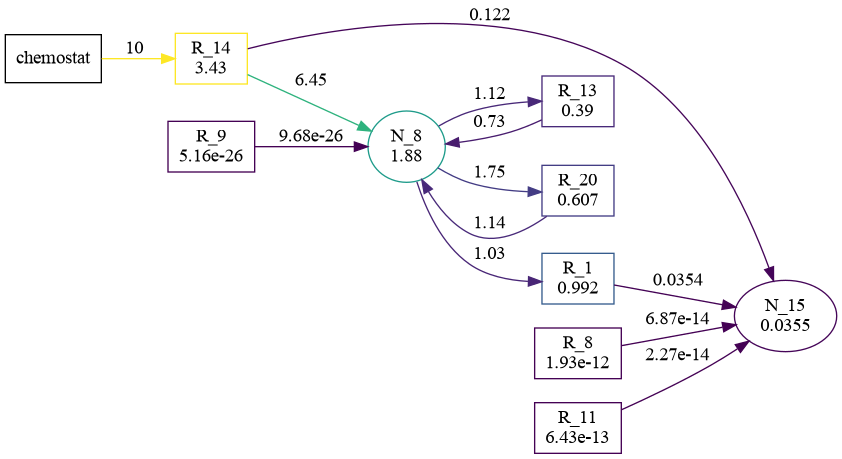

In [17]:
diagram_sfss_v3(sys_ps, hss;
    strain_threshold=1e-12,
)

In [18]:
(; ts, us) = load_pde_states(dirs[:data], ROW);

ts[ti] = 13213.518689002003

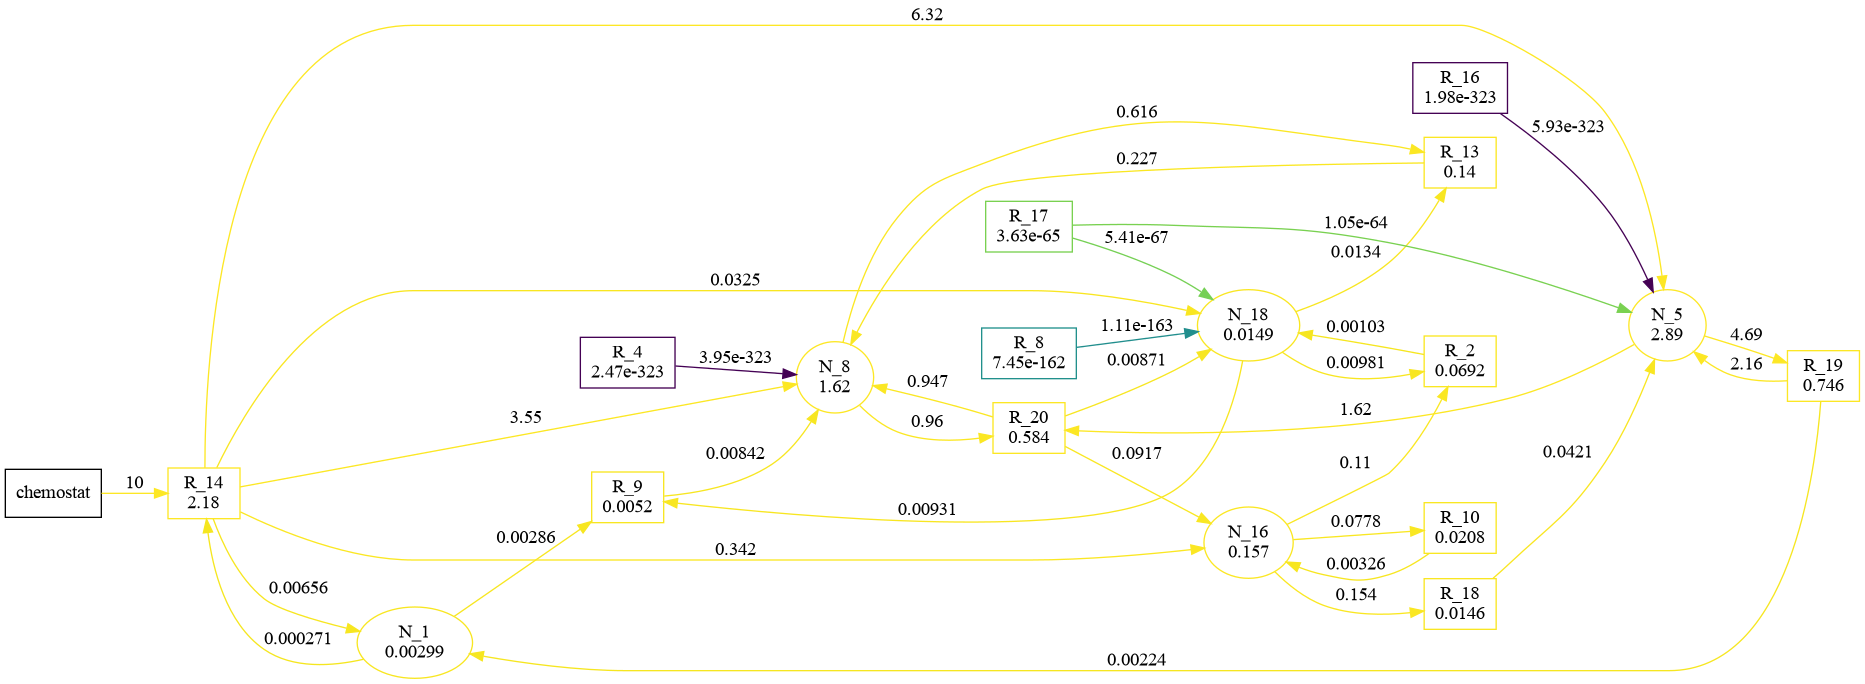

In [19]:
ti = 1057
@show ts[ti]
diagram_sfss_v3(sys_ps, mean(us[ti]; dims=2)[:];
    strain_threshold=1e-3, colorscale=log10,
)

# Space-time

One cell per plot style, both off the same reduced `spacetime`.

In [20]:
# one run at a time: 4700+ states of 40 x sN is ~1.5G, so reduce and drop.
# dx = 1/sN puts space on the x / L scale, tmin drops the saves before t = 1
spacetime = map(dirs) do dir
    (; ts, us) = load_pde_states(dir, ROW)
    d = spacetime_data(ts, us, Ns, 1 / sr.sN; tmin=1e0, max_nt=1000, max_nx=600)
    us = nothing
    GC.gc()
    d
end

sttitle(k) = @sprintf("row %d, %s - %s at t = %.4g",
    ROW, string(k), string(meta[k].retcode), meta[k].final_T)

map(x -> size(x.strains), spacetime)

[ Info: downsampled the space-time grid from 1000 x 4696 to 600 x 1000 (space x time)
[ Info: downsampled the space-time grid from 1000 x 5332 to 600 x 1000 (space x time)

(data = (20, 600, 1000), st4 = (20, 600, 1000))

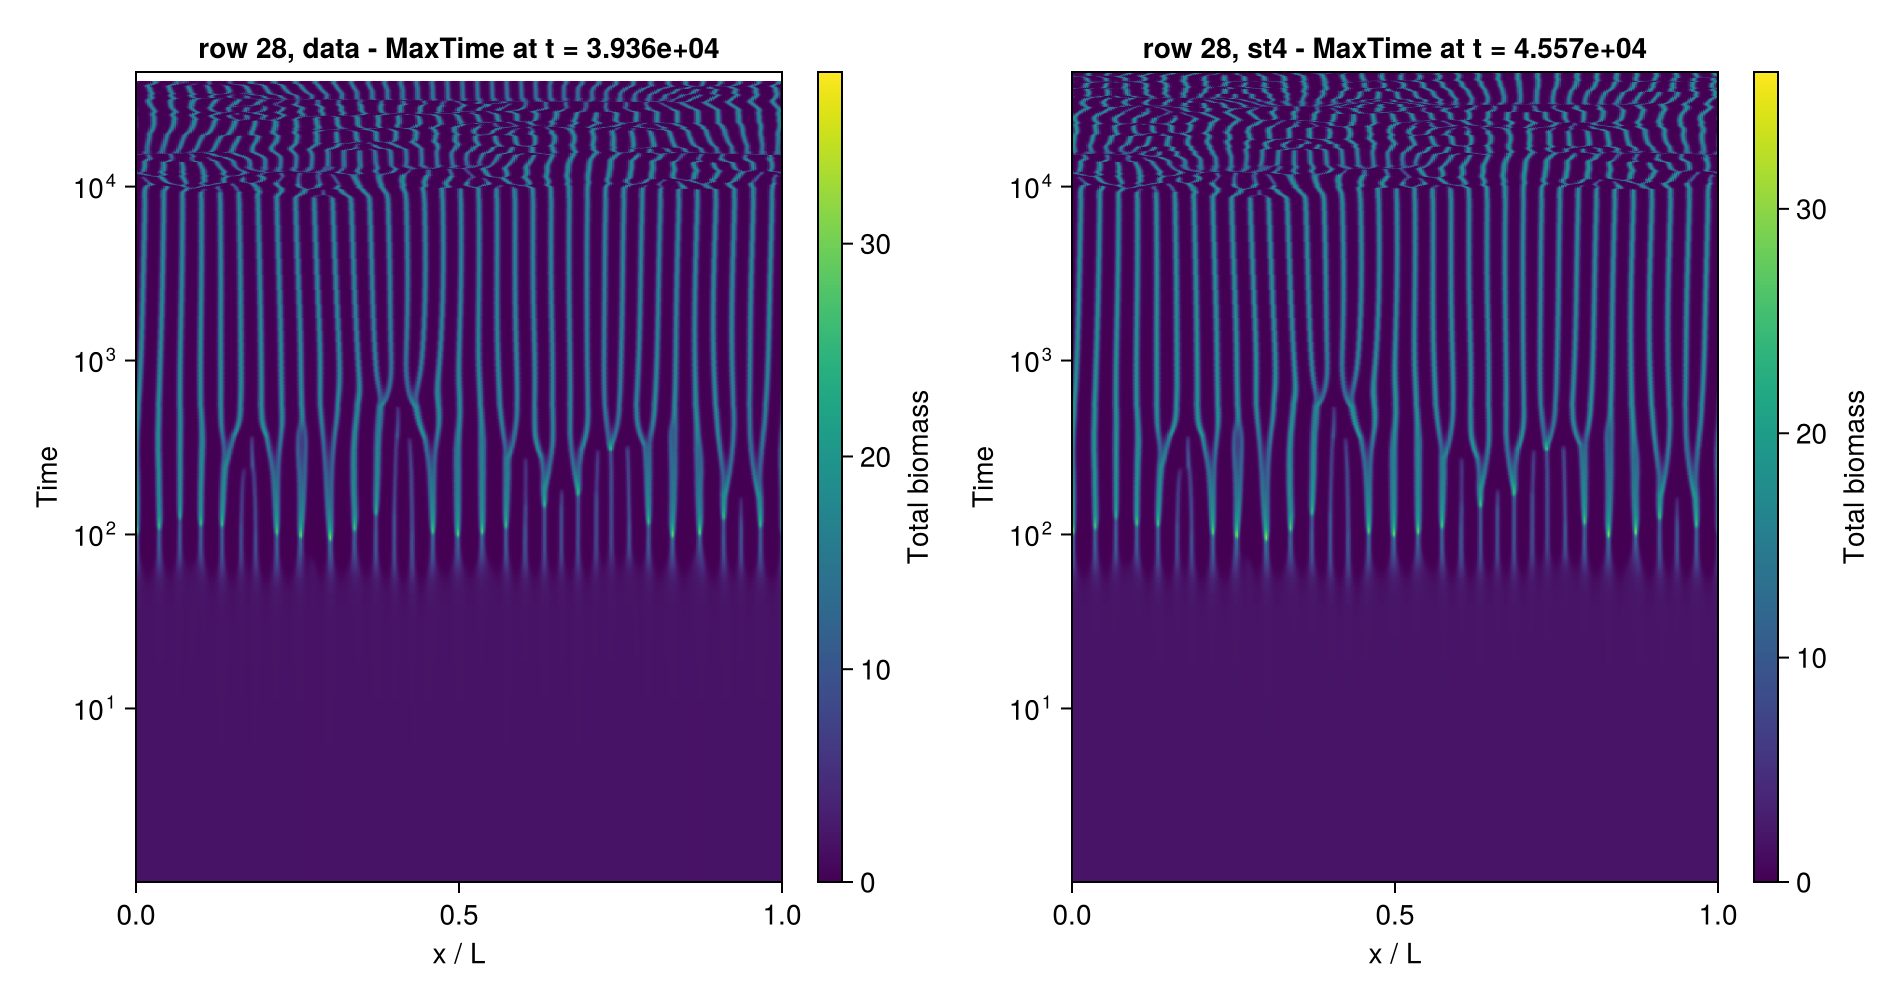

In [21]:
fig = Figure(; size=(950, 500))
axs = [plot_spacetime_biomass!(fig[1, kk], spacetime[k];
    colorbar=true, axis=(; xlabel="x / L", title=sttitle(k))).ax
       for (kk, k) in enumerate(order)]
linkaxes!(axs...)

fig

  3.027686 seconds (1.14 M allocations: 237.603 MiB, 28.38% compilation time)

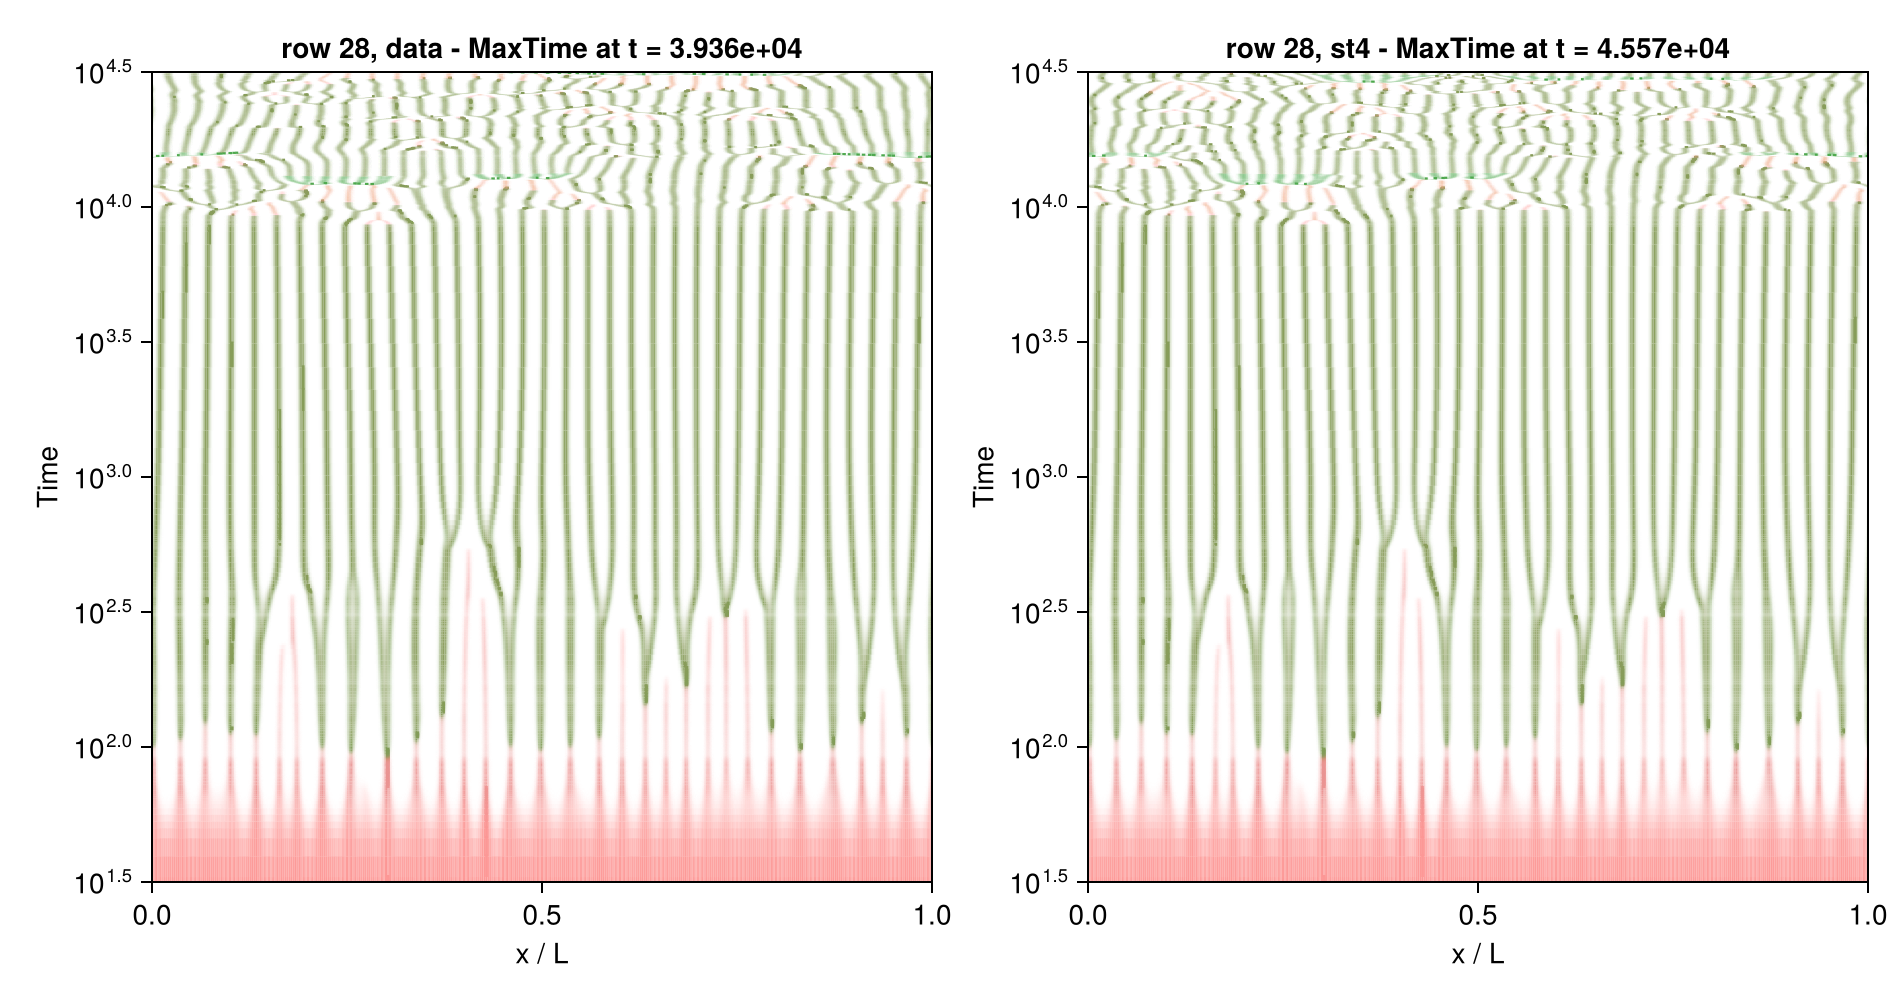

In [22]:
alphanorm = :time   # :global against the largest total in the run, :time against the largest in space at that t

fig = Figure(; size=(950, 500))
axs = []
for (kk, k) in enumerate(order)
    xx = plot_spacetime_composition!(fig[1, kk], spacetime[k];
        alphanorm,
        axis=(;
            xlabel="x / L",
            title=sttitle(k)
        )
    )
    xx.hm.rasterize = 10
    push!(axs, xx.ax)
end
linkaxes!(axs...)

ylims!(axs[2], 10^1.5, 10^4.5)
@time Makie.save("row28_spacetime.pdf", fig)
# display(GLMakie.Screen(), fig)

fig

# Final states, per strain

Strains holding at least `share_threshold` of the biomass get their own colour and
a legend entry; the rest are drawn in grey, since 20 distinct hues are not
tellable apart.

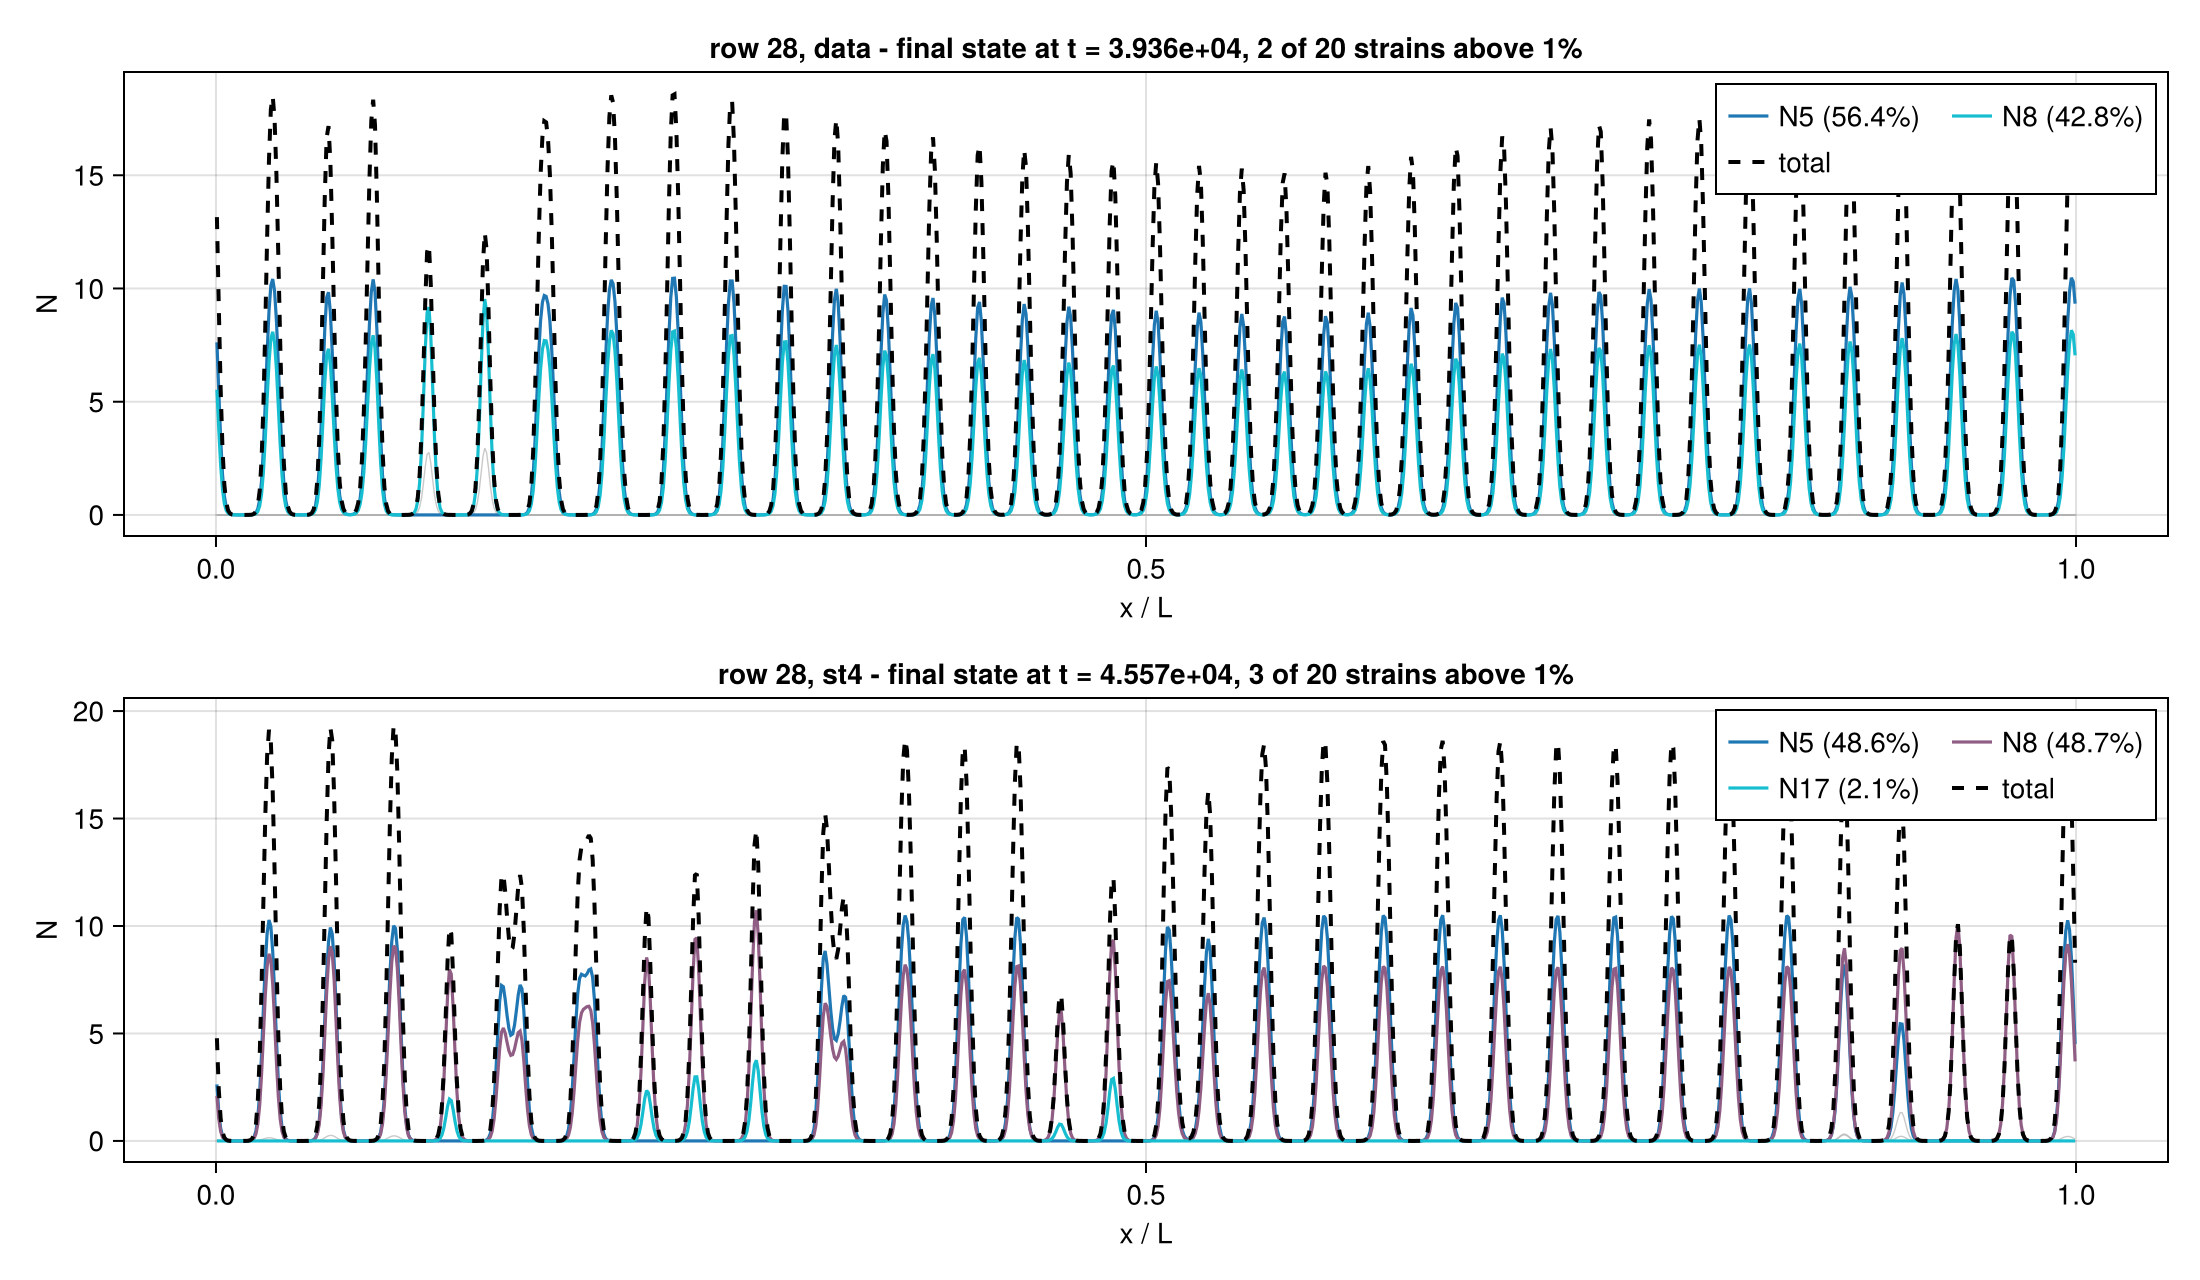

In [23]:
share_threshold = 0.01

fig = Figure(; size=(1100, 320 * length(order)))

for (kk, k) in enumerate(order)
    fs = meta[k].final_state
    tot = vec(sum(view(fs, 1:Ns, :), dims=1))
    share = [sum(view(fs, s, :)) for s in 1:Ns] ./ sum(tot)
    big = findall(>=(share_threshold), share)
    cols = Makie.resample_cmap(ColorSchemes.tab10, max(length(big), 2))

    ax = Axis(fig[kk, 1]; xlabel="x / L", ylabel="N",
        title=@sprintf("row %d, %s - final state at t = %.4g, %d of %d strains above %g%%",
            ROW, string(k), meta[k].final_T, length(big), Ns, 100share_threshold))
    for s in setdiff(1:Ns, big)
        lines!(ax, xs, fs[s, :]; color=(:grey70, 0.7), linewidth=0.7)
    end
    for (c, s) in enumerate(big)
        lines!(ax, xs, fs[s, :]; color=cols[c], linewidth=1.6,
            label=@sprintf("N%d (%.1f%%)", s, 100share[s]))
    end
    lines!(ax, xs, tot; color=:black, linewidth=2, linestyle=:dash, label="total")
    axislegend(ax; position=:rt, nbanks=2, framevisible=true)
end

fig

# Interactive: spatial state at a chosen save

GLMakie, opens in its own window. One run at a time - the two have different
numbers of saves on different time grids, so a shared index would not line them
up, and holding both series is ~3.2G.

In [25]:
which = :data      # :data or :st4

GLMakie.activate!()
(; ts, us) = load_pde_states(dirs[which], ROW)

ymaxN = maximum(maximum(view(u, 1:Ns, :)) for u in us)
ymaxR = maximum(maximum(view(u, (Ns+1):(Ns+Nr), :)) for u in us)

# every strain and resource is drawn. Only the ones carrying a share of the total
# get a legend entry - 20 a panel is unreadable - and the shares are summed over
# the whole series, so a colour and a label mean the same at every slider position.
tot_s = [sum(sum(view(u, s, :)) for u in us) for s in 1:Ns]
tot_r = [sum(sum(view(u, Ns + a, :)) for u in us) for a in 1:Nr]
share_s = tot_s ./ sum(tot_s)
share_r = tot_r ./ sum(tot_r)
bigN = findall(>=(share_threshold), share_s)
bigR = findall(>=(share_threshold), share_r)

ncols = Makie.resample_cmap(ColorSchemes.tab20, Ns)
rcols = Makie.resample_cmap(ColorSchemes.tab20b, Nr)

fig = Figure(; size=(1000, 700))
sl = Slider(fig[3, 1], range=eachindex(ts), startvalue=length(ts))
u_at = lift(i -> us[i], sl.value)

axN = Axis(fig[1, 1]; ylabel="N",
    title=lift(i -> @sprintf("row %d, %s - save %d of %d, t = %.6g", ROW, string(which), i, length(ts), ts[i]), sl.value))
pN = [lines!(axN, xs, lift(u -> u[s, :], u_at); color=ncols[s], linewidth=1) for s in 1:Ns]
ptot = lines!(axN, xs, lift(u -> vec(sum(view(u, 1:Ns, :), dims=1)), u_at); color=:black, linestyle=:dash, linewidth=1)
ylims!(axN, -0.02ymaxN, 1.05ymaxN)
axislegend(axN, vcat(pN[bigN], [ptot]),
    vcat([@sprintf("N%d (%.1f%%)", s, 100share_s[s]) for s in bigN], ["total"]);
    position=:rt, nbanks=2, framevisible=true)

axR = Axis(fig[2, 1]; xlabel="x / L", ylabel="R")
pR = [lines!(axR, xs, lift(u -> u[Ns+a, :], u_at); color=rcols[a], linewidth=1) for a in 1:Nr]
ylims!(axR, -0.02ymaxR, 1.05ymaxR)
axislegend(axR, pR[bigR], [@sprintf("R%d (%.1f%%)", a, 100share_r[a]) for a in bigR];
    position=:rt, nbanks=2, framevisible=true)

# left/right arrows step one save; hold to repeat. Needs the GLMakie window focused.
on(events(fig).keyboardbutton) do e
    if e.action in (Keyboard.press, Keyboard.repeat)
        i, r = sl.value[], sl.range[]
        e.key == Keyboard.left && set_close_to!(sl, max(first(r), i - 1))
        e.key == Keyboard.right && set_close_to!(sl, min(last(r), i + 1))
    end
    Consume(false)
end

linkxaxes!(axN, axR)
hidexdecorations!(axN; grid=false)
Label(fig[4, 1], "drag the slider or use left/right arrows; ylims are fixed to the whole series so frames are comparable";
    color=:grey50, tellwidth=false)

display(GLMakie.Screen(), fig)
# fig

GLMakie.Screen(...)